<a href="https://colab.research.google.com/github/shivani5015/Machine-learning-Roadmap/blob/main/8k_means_cluster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# K-Means Clustering Cheat Sheet

---

## What Is K-Means?
An **Unsupervised Learning Algorithm** that groups unlabeled data into $K$ distinct clusters by minimizing the distance between data points and their cluster centers (**Centroids**).

---

## How It Works (4-Step Loop)

1. **Pick $K$:** Set the number of clusters.
2. **Init Centroids:** Place $K$ initial center points (preferably using `k-means++`).
3. **Assign:** Group each point with its closest centroid (using Euclidean Distance).
4. **Update & Repeat:** Recalculate centroids as the mean of their points. Repeat until centroids stop moving (**Convergence**).

---

## Finding Optimal $K$: The Elbow Method
* **Inertia (WCSS):** Sum of squared distances from points to their centroid.
* **Elbow Rule:** Plot Inertia against different $K$ values. Pick $K$ at the **sharp bend (elbow point)** where Inertia drop slows down.

---

## Key Best Practice: K-Means++
* Standard random initialization can lead to poor clusters.
* Always use `init='k-means++'`—it places initial centroids far apart for faster and better convergence.

In [ ]:
df=pd.read_csv("/content/mall - mall.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df=df.drop(columns=['CustomerID','Genre'])


In [ ]:
df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [ ]:
x=df.iloc[:,[0,1]].values
#X = df[['Age', 'EstimatedSalary']].values

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
import matplotlib.pyplot as plt


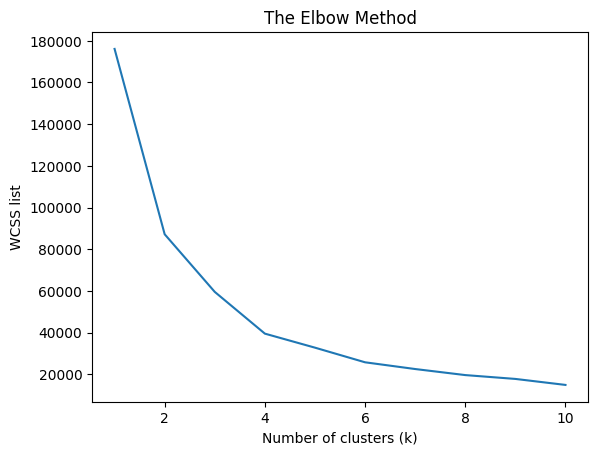

In [ ]:
a=[]
for i in range(1,11):
  b=KMeans(n_clusters=i,init='k-means++',random_state=42)
  b.fit(x)
  a.append(b.inertia_)

plt.plot(range(1,11),a)

plt.title('The Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS list')
plt.show()

In [ ]:
#from the above plot, we can see the elbow point is at 4 so the number pf clusters here will be 4.

In [ ]:
b=KMeans(n_clusters=4,init='k-means++',random_state=42)
y_predict=b.fit_predict(x)



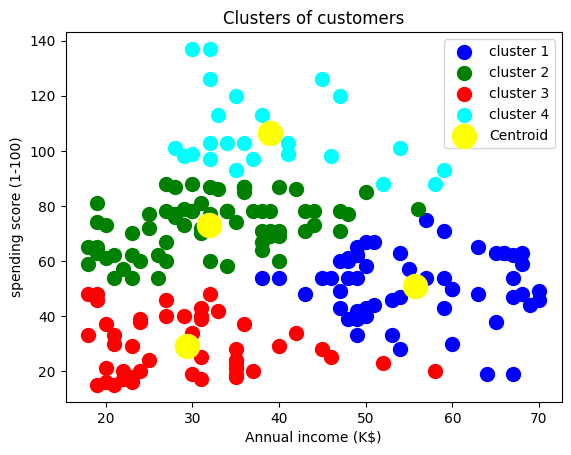

In [ ]:
plt.scatter(x[y_predict==0,0],x[y_predict==0,1],s=100,c='blue',label='cluster 1')
plt.scatter(x[y_predict==1,0],x[y_predict==1,1],s=100,c='green',label='cluster 2')
plt.scatter(x[y_predict==2,0],x[y_predict==2,1],s=100,c='red',label='cluster 3')
plt.scatter(x[y_predict==3,0],x[y_predict==3,1],s=100,c='cyan',label='cluster 4')

plt.scatter(b.cluster_centers_[:,0],b.cluster_centers_[:,1],s=300,c='yellow',label='Centroid')
plt.title('Clusters of customers')
plt.xlabel('Annual income (K$)')
plt.ylabel('spending score (1-100)')
plt.legend()
plt.show()
